 # Netflix Country Contribution Analysis
 Which country contributes the most titles to Netflix, nd how has that changed over time?

##### Author - Thembela Thandokazi (Thando) Voyizana
1. linkedin - https://www.linkedin.com/in/thembela-thandokazi-voyizana/
2. github - https://github.com/ThandokaziVoyizana
3. email - voyizanathandokazi@gmail.com
4. whatsApp - +2778 7813 634

## Key Goals 
- Identify the top contributing country
- Analyze how its contributions evolve over time
- Visualize trends using clear plots

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 12

In [4]:
# load netflix data
df = pd.read_csv("netflix_titles.csv")
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


## Data Cleaning

- Convert `date_added` to datetime format
- Extract the year for trend analysis
- Remove missing values in the country column


In [7]:
# date_added looks like 'September 25, 2021' (with some stray spaces)
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), format='mixed', errors='coerce')
df['year_added'] = df['date_added'].dt.year


In [8]:
# Remove missing countries
df = df.dropna(subset=['country'])

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0


In [9]:
# counts all values in the 'type' column
df['country'].value_counts(normalize=True)


country
United States                                    0.353310
India                                            0.121866
United Kingdom                                   0.052533
Japan                                            0.030717
South Korea                                      0.024950
                                                   ...   
Russia, Spain                                    0.000125
Croatia, Slovenia, Serbia, Montenegro            0.000125
Japan, Canada                                    0.000125
United States, France, South Korea, Indonesia    0.000125
United Arab Emirates, Jordan                     0.000125
Name: proportion, Length: 748, dtype: float64

## Handling Multiple Countries
### Split them into individual rows so each country is counted correctly.


Some titles are produced by multiple countries.  


In [11]:
# Split multiple countries into separate rows
df_country = df.dropna(subset=['country']).copy()
df_country = df_country.assign(
    country=df_country['country'].str.split(',')
).explode('country')

# Remove spaces
df_country['country'] = df_country['country'].str.strip()

## Top Contributing Country

We count how many titles each country has contributed.

In [31]:
# Count titles per country
country_counts = df_country['country'].value_counts()
top_country = country_counts.idxmax()
top_country_count = country_counts.max()

# Print results
print("Top country:", top_country)
print("Number of titles:", top_country_count)



Top country: United States
Number of titles: 3690


In [40]:
# Group by year and country
year_country = df.groupby(["year_added", "country"]).size().reset_index(name="count")

# Focus on top 5 countries
top5_list = top_countries.head(5).index
trend = year_country[year_country["country"].isin(top5_list)]

# Pivot for plotting
trend_pivot = trend.pivot(index="year_added", columns="country", values="count").fillna(0)

trend_pivot.head()

country,India,Japan,South Korea,United Kingdom,United States
year_added,,,,,
2008.0,0.0,0.0,0.0,0.0,2.0
2009.0,0.0,0.0,0.0,0.0,1.0
2010.0,0.0,0.0,0.0,0.0,1.0
2011.0,0.0,0.0,0.0,0.0,11.0
2012.0,0.0,0.0,0.0,0.0,2.0


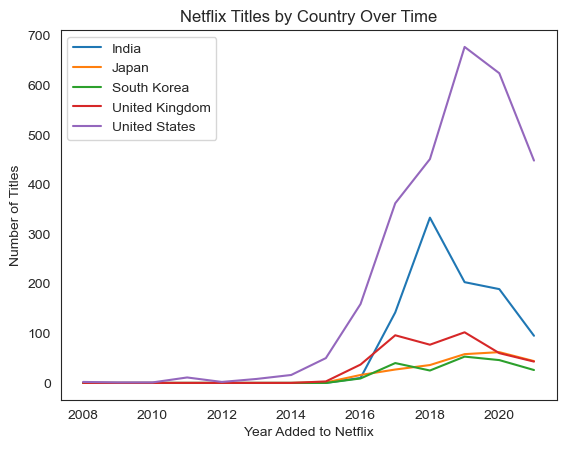

In [44]:
plt.figure()
for col in trend_pivot.columns:
    plt.plot(trend_pivot.index, trend_pivot[col], label=col)

plt.title("Netflix Titles by Country Over Time")
plt.xlabel("Year Added to Netflix")
plt.ylabel("Number of Titles")
plt.legend()
plt.show()

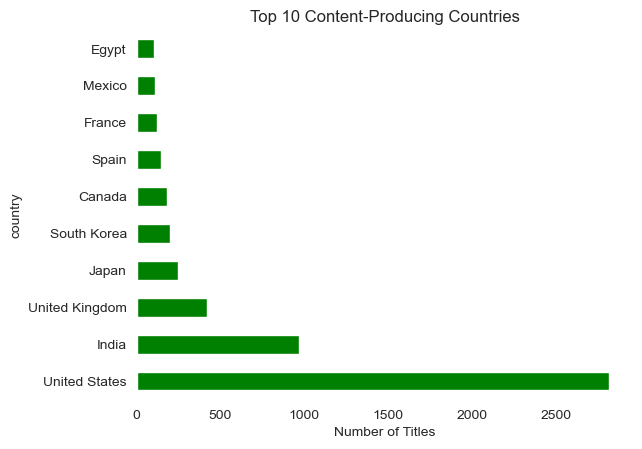

In [23]:
top_countries = df['country'].value_counts().head(10)
# Create the plot
ax = top_countries.plot(
    kind='barh',
    color='green'
)

plt.title("Top 10 Content-Producing Countries")
plt.xlabel("Number of Titles")

# Remove borders
for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.savefig("netflix_top10_countries.png")
plt.show()


## Conclusion

- The **United States contributes the most titles**
- Its dominance has remained consistent over time
- There is growing global participation from other countries
- Netflix’s content library is becoming more internationally diverse
